# Fixed Income Positioning Score — Bloomberg / BQuant (Track B)

Same methodology as the free Track A (`positioning/run_positioning.py`), but sourced from
Bloomberg via **`bql`** and optimized to run inside **BQNT**.

The scoring engine is **`positioning.core`** — identical to Track A. This notebook only
swaps the *data adapter*: it builds the same three standardized frames
(`FuturesPanel`, `CashPanel`, `YieldsFrame` — see `positioning/core/schema.py`) from
Bloomberg fields, then calls `positioning.core.score.run_score`.

**Design contract:** if `bql` is unavailable (running outside BQNT), the notebook falls
back to the Track A CSV cache so the full pipeline still executes end-to-end. This lets you
validate structure now and flip to live Bloomberg data in BQuant with no code change.

> **Advantage of the BBG track:** exact CTD DV01 (RISK_MID on the cheapest-to-deliver),
> plus optional richer inputs unavailable for free — TY options skew / risk-reversals and
> swap-dealer positioning — which can be appended to the same panels.

## 1. Environment & imports
Make the repo root importable so `positioning.core` resolves inside BQuant.

In [1]:
import sys, os
from pathlib import Path

# BQuant working dir varies; point REPO_ROOT at the folder that contains `positioning/`.
REPO_ROOT = Path.cwd()
while REPO_ROOT != REPO_ROOT.parent and not (REPO_ROOT / "positioning").exists():
    REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT))

import numpy as np
import pandas as pd

from positioning.config import CONTRACTS, NYFED_CASH_SERIES, DEFAULT_START
from positioning.core import score as score_mod

try:
    import bql
    bq = bql.Service()
    HAVE_BQL = True
    print("bql available — using live Bloomberg data")
except Exception as e:
    HAVE_BQL = False
    print(f"bql unavailable ({type(e).__name__}) — falling back to Track A cache")

bql unavailable (ModuleNotFoundError) — falling back to Track A cache


## 2. Bloomberg tickers & CFTC field mnemonics

Front-contract tickers for the US Treasury futures complex, keyed by the same internal
instrument keys used by `positioning.config.CONTRACTS` (TU/FV/TY/TN/US/UB).

> **⚠️ Verify the CFTC field mnemonics in `FLDS <GO>` on a COT-enabled ticker.** Bloomberg's
> exact CFTC Traders-in-Financial-Futures field names differ by terminal/data entitlement.
> The names below are the *intended* mapping; confirm and adjust once, here, and nothing
> downstream changes.

In [2]:
# internal key -> Bloomberg generic front-contract ticker
BBG_TICKERS = {
    "TU": "TU1 Comdty",   # 2Y
    "FV": "FV1 Comdty",   # 5Y
    "TY": "TY1 Comdty",   # 10Y
    "TN": "UXY1 Comdty",  # Ultra 10Y
    "US": "US1 Comdty",   # Classic Bond
    "UB": "WN1 Comdty",   # Ultra Bond
}

# TFF category -> (long_field, short_field) Bloomberg mnemonics. VERIFY in FLDS <GO>.
BBG_TFF_FIELDS = {
    "lev_money": ("CFTC_FINANCIAL_LEVERAGED_FUNDS_LONG", "CFTC_FINANCIAL_LEVERAGED_FUNDS_SHORT"),
    "asset_mgr": ("CFTC_FINANCIAL_ASSET_MANAGER_LONG",   "CFTC_FINANCIAL_ASSET_MANAGER_SHORT"),
    "dealer":    ("CFTC_FINANCIAL_DEALER_LONG",          "CFTC_FINANCIAL_DEALER_SHORT"),
}
BBG_OI_FIELD = "OPEN_INT"
BBG_CONC_FIELDS = ("CFTC_NET_CONCENTRATION_LONG", "CFTC_NET_CONCENTRATION_SHORT")

# yield tickers -> the DGS* column names the core expects (config.ContractSpec.fred_yield)
BBG_YIELDS = {"USGG2YR Index": "DGS2", "USGG5YR Index": "DGS5",
              "USGG10YR Index": "DGS10", "USGG30YR Index": "DGS30"}

## 3. Bloomberg adapter → standardized panels

Each function returns exactly the schema `positioning.core` consumes. Batches requests per
`bql` best practice (one request across tickers where possible).

In [3]:
def _bql_frame(tickers, field, start):
    """Fetch one field across tickers as a tidy DataFrame [date, ticker, value]."""
    req = bql.Request(list(tickers),
                      {field: bq.data[field](dates=bq.func.range(start, "0D"), frq="W")})
    res = bq.execute(req)
    df = res[0].df().reset_index()
    df.columns = ["ticker", "date", "value"][:len(df.columns)]
    return df


def fetch_futures_bbg(start=DEFAULT_START):
    """Build the standardized FuturesPanel from Bloomberg CFTC fields."""
    inv = {v: k for k, v in BBG_TICKERS.items()}
    rows = []
    for cat, (lf, sf) in BBG_TFF_FIELDS.items():
        longs = _bql_frame(BBG_TICKERS.values(), lf, start)
        shorts = _bql_frame(BBG_TICKERS.values(), sf, start)
        oi = _bql_frame(BBG_TICKERS.values(), BBG_OI_FIELD, start)
        m = (longs.merge(shorts, on=["ticker", "date"], suffixes=("_l", "_s"))
                   .merge(oi.rename(columns={"value": "oi"}), on=["ticker", "date"]))
        for _, r in m.iterrows():
            rows.append({
                "date": pd.Timestamp(r["date"]).tz_localize(None),
                "instrument": inv[r["ticker"]],
                "category": cat,
                "net_contracts": r["value_l"] - r["value_s"],
                "open_interest": r["oi"],
                "conc_net_top4_long": np.nan,   # optionally fill from BBG_CONC_FIELDS
                "conc_net_top4_short": np.nan,
            })
    return pd.DataFrame(rows)


def fetch_yields_bbg(start=DEFAULT_START):
    """Wide YieldsFrame with columns renamed to the DGS* names the core expects."""
    df = _bql_frame(BBG_YIELDS.keys(), "PX_LAST", start)
    wide = df.pivot_table(index="date", columns="ticker", values="value")
    wide = wide.rename(columns=BBG_YIELDS)
    wide.index = pd.to_datetime(wide.index).tz_localize(None)
    return wide.sort_index()


def fetch_cash_bbg(start=DEFAULT_START):
    """Cash leg. Bloomberg has no direct primary-dealer-by-tenor equivalent; return empty
    (futures-only) or wire in FR2004 via the NY Fed adapter alongside BBG futures."""
    return pd.DataFrame(columns=["date", "tenor_years", "net_value"])

## 4. Build panels (Bloomberg, or Track A cache fallback)

In [4]:
if HAVE_BQL:
    futures = fetch_futures_bbg()
    yields = fetch_yields_bbg()
    cash = fetch_cash_bbg()
    print("Loaded live Bloomberg panels")
else:
    # Fallback: reuse the free Track A adapters/cache so the core still runs end-to-end.
    from positioning.adapters import cftc_free, nyfed_free, yields_free
    futures = cftc_free.fetch_cftc_tff()
    cash = nyfed_free.fetch_nyfed_cash()
    yields = yields_free.fetch_yields()
    print("Loaded Track A cache panels (structure test)")

print("futures:", futures.shape, "| cash:", cash.shape, "| yields:", yields.shape)
futures.head()

Loaded Track A cache panels (structure test)
futures: (16734, 7) | cash: (3923, 3) | yields: (5236, 4)


,date,instrument,category,net_contracts,open_interest,conc_net_top4_long,conc_net_top4_short
0,2006-06-13,US,lev_money,43365,762787,18.2,18.3
1,2006-06-13,US,asset_mgr,26148,762787,18.2,18.3
2,2006-06-13,US,dealer,9632,762787,18.2,18.3
3,2006-06-13,TU,lev_money,-90482,531799,21.1,13.4
4,2006-06-13,TU,asset_mgr,108079,531799,21.1,13.4


## 5. Score — identical core to Track A

`run_score` applies DV01 conversion → hierarchical aggregation → PCA factors → calibrated
probability overlay → contrarian signal, with the same publication-lag leakage guards.

In [5]:
res = score_mod.run_score(futures, cash, yields)
import json
print(json.dumps(res.latest, indent=2, default=str))

{
  "as_of": "2026-06-30",
  "composite_z": 2.512970465189984,
  "percentile": 0.9102564102564102,
  "equal_weight_z": 2.4243811365711787,
  "category_level_z": {
    "lev_money": -0.12756851494697646,
    "asset_mgr": 1.2267304055637633
  },
  "curve_z": 1.3530008287770008,
  "concentration_z": 1.707387103396462,
  "cash_z": 1.8502816228034527,
  "stance": -1,
  "stance_text": "short duration (fade crowded longs)",
  "p_selloff_next_4w": 0.43128992099930424,
  "pca_explained_var": [
    0.3378139792651291,
    0.27712949341253773
  ]
}


## 6. Inline diagnostics
Composite crowding index, PCA loadings, and the walk-forward probability overlay.

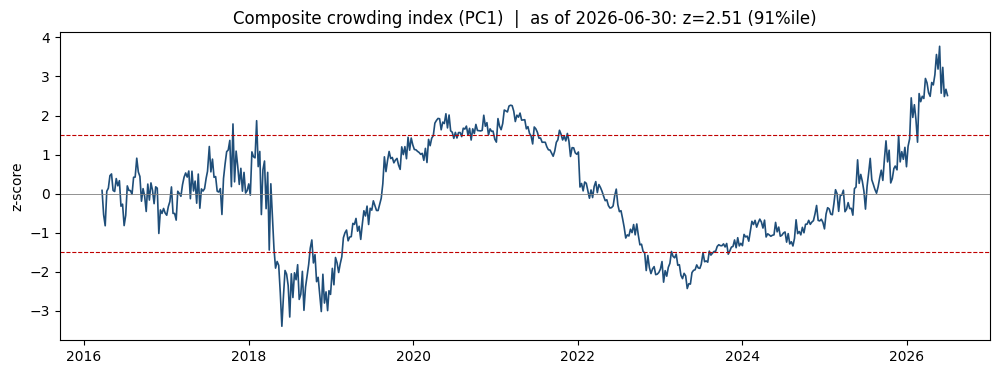

PCA explained variance: [0.338, 0.277]


,PC1,PC2
lev_money_level_z,0.504,-0.178
lev_money_flow_z,0.155,-0.567
asset_mgr_level_z,-0.472,0.230
asset_mgr_flow_z,-0.068,0.608
curve_z,0.408,0.223
conc_z,0.332,0.301
cash_z,-0.468,-0.290


Walk-forward metrics: {'n_oos': 376, 'base_rate': 0.5212765957446809, 'auc': 0.542063492063492, 'log_loss': 0.6912922922043804, 'brier': 0.249138737684625, 'horizon_note': 'OOS via expanding-window walk-forward'}


In [6]:
import matplotlib.pyplot as plt
from positioning.config import SIGNAL_K_ENTRY

comp = res.composite.dropna()
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(comp.index, comp.values, color="#1f4e79", lw=1.2)
ax.axhline(SIGNAL_K_ENTRY, color="#c00000", ls="--", lw=0.8)
ax.axhline(-SIGNAL_K_ENTRY, color="#c00000", ls="--", lw=0.8)
ax.axhline(0, color="grey", lw=0.6)
ax.set_title("Composite crowding index (PC1)  |  as of %s: z=%.2f (%.0f%%ile)" % (
    res.latest["as_of"], res.latest["composite_z"], 100*res.latest["percentile"]))
ax.set_ylabel("z-score")
plt.show()

print("PCA explained variance:", [round(v, 3) for v in res.factors.explained_var])
display(res.factors.loadings.round(3))
print("Walk-forward metrics:", res.predictive.metrics)

## 7. Next steps for the Bloomberg build
- Confirm the CFTC TFF field mnemonics in **`FLDS <GO>`** and update `BBG_TFF_FIELDS`.
- Replace the approximate contract DV01 with **exact CTD DV01** by pulling `RISK_MID` on the
  cheapest-to-deliver and passing it through `positioning.core.dv01` (drop-in — the core only
  ever sees DV01).
- Append richer inputs to the panels: **TY options skew / risk-reversals** and
  **swap-dealer positioning** as extra `category`/feature columns; the PCA layer absorbs them
  automatically.
